# Clasificación Básica: Predecir una imagen de moda

Esta Guia entrena un modelo de red neuronal para clasificar imagenes de ropa como, tennis y camisetas.

Esta Guia usa [tf.keras](https://www.tensorflow.org/guide/keras), un API de alto nivel para construir y entrenar modelos en Tensorflow.

## Importar el set de datos de moda de MNIST

Esta guia usa el set de datos de [Fashion MNIST](https://github.com/zalandoresearch/fashion-mnist)
que contiene mas de 70,000 imagenes en 10 categorias. Las imagenes muestran articulos individuales de ropa a una resolucion baja (28 por 28 pixeles) como se ve aca:

<table>
  <tr><td>
    <img src="https://tensorflow.org/images/fashion-mnist-sprite.png"
         alt="Fashion MNIST sprite"  width="600">
  </td></tr>
  <tr><td align="center">
    <b>Figure 1.</b> <a href="https://github.com/zalandoresearch/fashion-mnist">Fashion-MNIST samples</a> (by Zalando, MIT License).<br/>&nbsp;
  </td></tr>
</table>

Para importar y cargar el set de datos de MNIST directamente de TensorFlow:

In [65]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn import metrics
import numpy as np

from tensorflow import keras
np.set_printoptions(suppress=True, precision=12)

La *class* de ropa que la imagen representa.

<table>
  <tr>
    <th>Label</th>
    <th>Class</th>
  </tr>
  <tr>
    <td>0</td>
    <td>T-shirt/top</td>
  </tr>
  <tr>
    <td>1</td>
    <td>Trouser</td>
  </tr>
    <tr>
    <td>2</td>
    <td>Pullover</td>
  </tr>
    <tr>
    <td>3</td>
    <td>Dress</td>
  </tr>
    <tr>
    <td>4</td>
    <td>Coat</td>
  </tr>
    <tr>
    <td>5</td>
    <td>Sandal</td>
  </tr>
    <tr>
    <td>6</td>
    <td>Shirt</td>
  </tr>
    <tr>
    <td>7</td>
    <td>Sneaker</td>
  </tr>
    <tr>
    <td>8</td>
    <td>Bag</td>
  </tr>
    <tr>
    <td>9</td>
    <td>Ankle boot</td>
  </tr>
</table>

Cada imagen es mapeada a una unica etiqueta. Ya que los *Class names* no estan incluidos en el dataset.

In [3]:
class_name = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat", "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]

In [9]:
f_mnist = keras.datasets.fashion_mnist
data = f_mnist.load_data()

In [74]:
(X_train_f, y_train_f), (X_test_f, y_test_f) = f_mnist.load_data()

## Explore el set de datos

* ¿Cuántas imágenes hay en train?
* ¿Y en test?
* ¿De cuántos pixels se compone cada imagen?
* ¿Cuáles son los valores de los labels?

In [75]:
print("Img Train: ", X_train_f.shape[0])
print("Img Train: ", X_test_f.shape[0])
print("pixels: ", X_train_f.shape[1] * X_train_f.shape[2])
print(X_test_f[0].size)


Img Train:  60000
Img Train:  10000
pixels:  784
784


In [76]:
print(pd.Series(y_train_f).value_counts())

9    6000
0    6000
3    6000
2    6000
7    6000
5    6000
1    6000
6    6000
4    6000
8    6000
Name: count, dtype: int64


## Pre-procese el set de datos

Inspecciona y representa la primera imagen del dataset de train. Para ello, utiliza la función `imshow` de matplotlib.

In [22]:
class_name[9]

'Ankle boot'

Text(0.5, 1.0, 'Ankle boot')

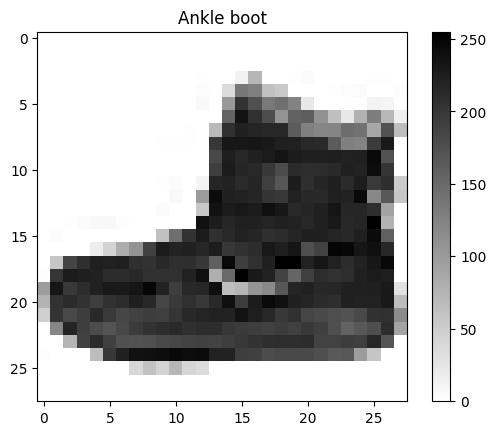

In [77]:
plt.imshow(X_train_f[0], cmap="binary")
plt.colorbar()
plt.title(class_name[y_train_f[0]])

Escala los conjuntos de train y test para que vayan del 0 al 1. No hace falta usar ninguna librería. Con realizar una división en cada conjunto será suficiente.

In [78]:
X_train = X_train_f/255
X_test = X_test_f/255

In [79]:
print(X_train.min())
print(X_train.max())

0.0
1.0


Para verificar que el set de datos está en el formato adecuado y que están listos para construir y entrenar la red, vamos a desplegar las primeras 25 imágenes del *training set* y despleguemos el nombre de cada clase debajo de cada imagen.

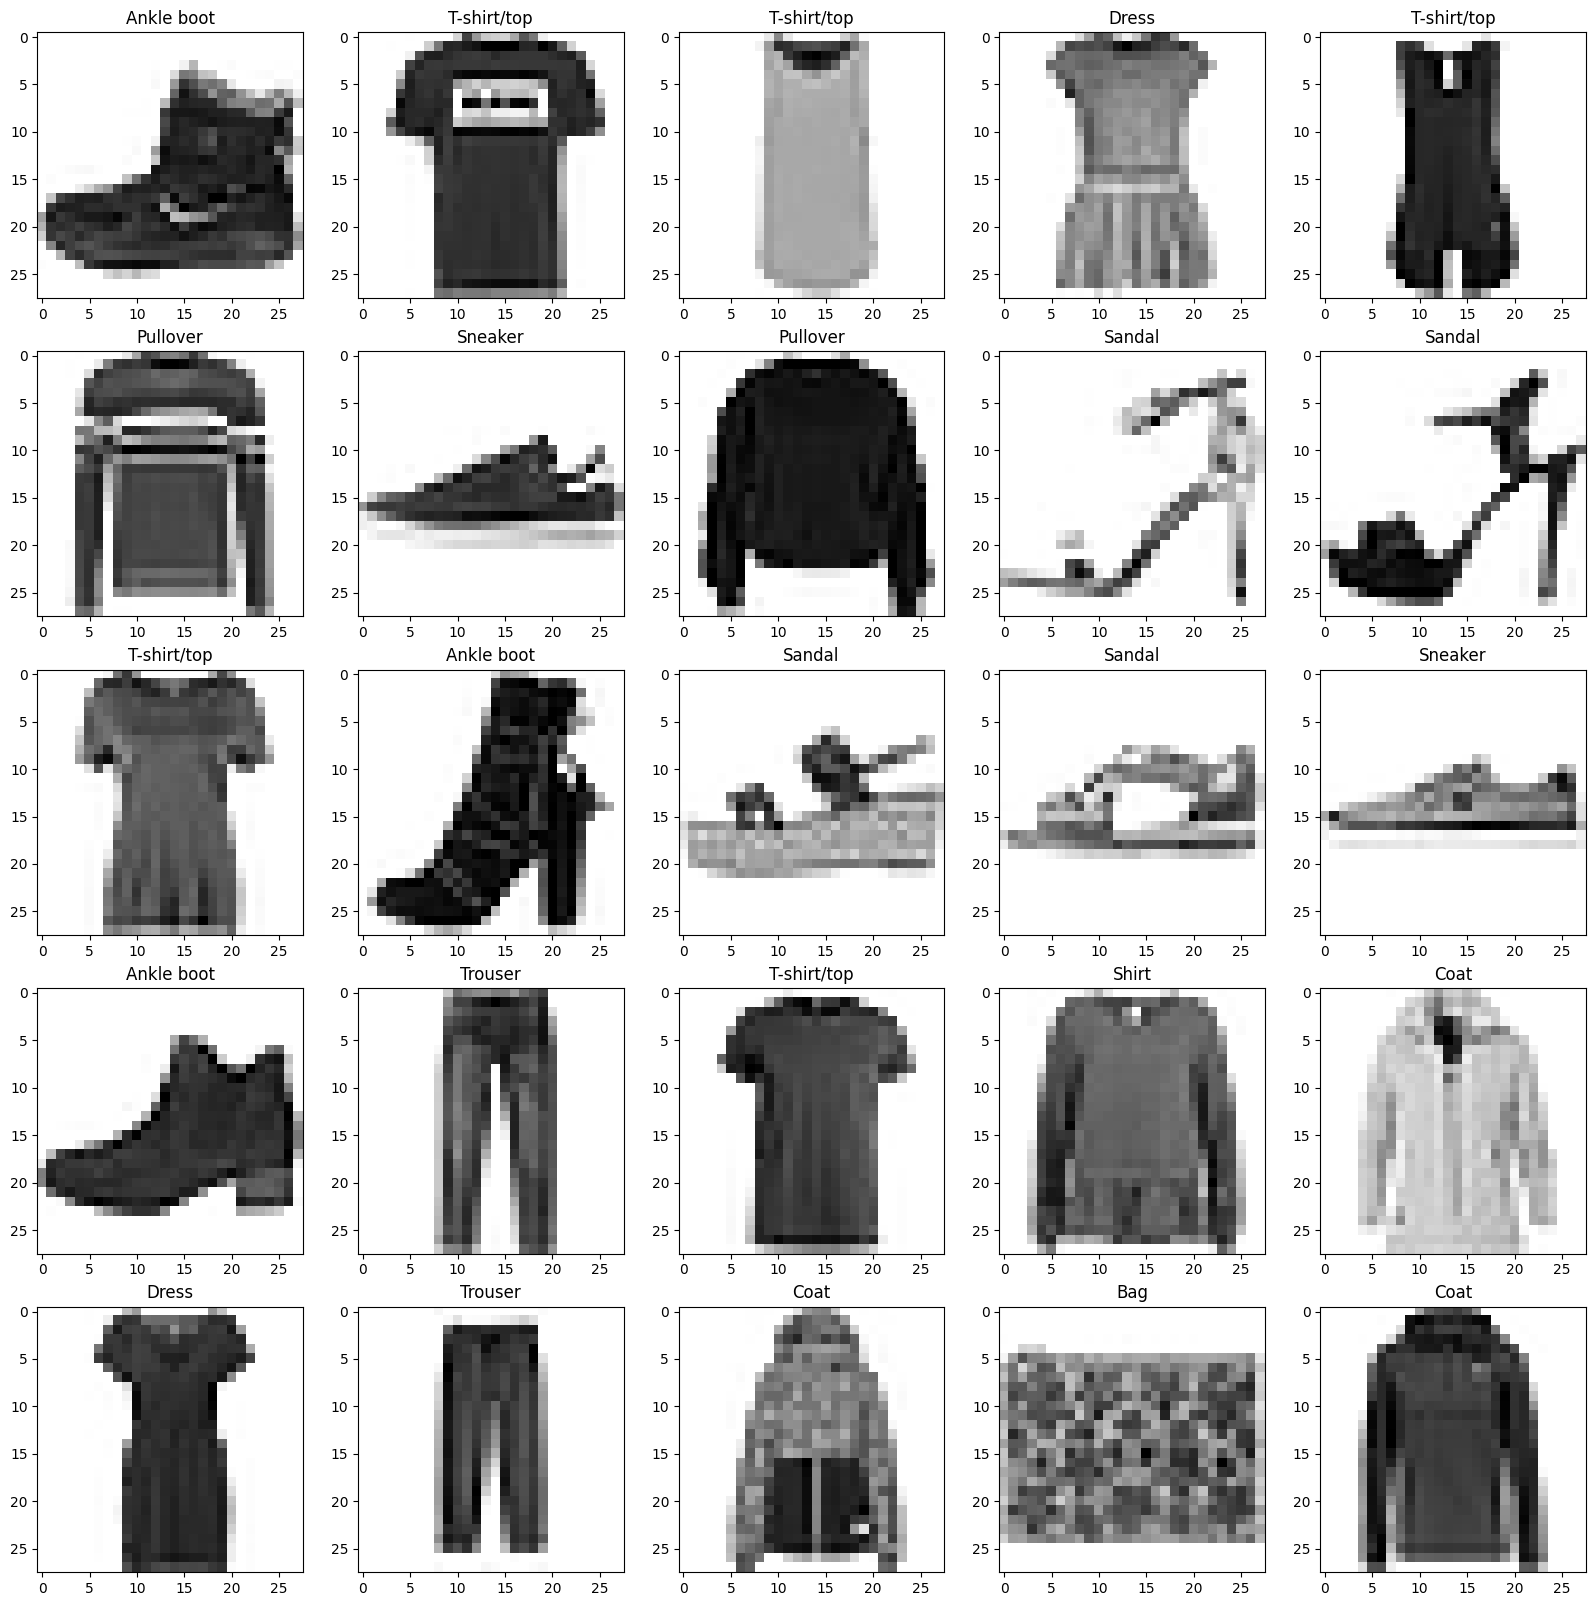

In [ ]:
plt.figure(figsize=(20,20))
for i in range(25):
    plt.subplot(5,5, i+1)
    plt.imshow(X_train[i], cmap = "binary")
    plt.title(class_name[y_train_f[i]])

## Construir el Modelo

Construir la red neuronal requiere configurar las capas del modelo y luego compilar el modelo.

### Configurar las Capas
Construye todas las capas del modelo.

In [41]:
X_train_flat = X_train.reshape(-1, 28*28)
X_test_flat = X_test.reshape(-1, 28*28)

In [48]:
modelo = keras.Sequential([
    keras.layers.Dense(128, input_shape = (784,)),
    keras.layers.Dense(64, activation="relu"),
    keras.layers.Dense(32, activation="relu"),
    keras.layers.Dense(10, activation="softmax")
])

modelo.summary()

c:\Users\Diego Nuñez\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\core\dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_16 (Dense)                │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 111,146 (434.16 KB)

 Trainable params: 111,146 (434.16 KB)

 Non-trainable params: 0 (0.00 B)

### Compila el modelo

Antes de que el modelo este listo para entrenar , se necesitan algunas configuraciones más. Estas son agregadas durante el paso de compilacion del modelo:

* *Loss function* —Esto mide que tan exacto es el modelo durante el entrenamiento. Quiere minimizar esta función para dirigir el modelo en la dirección adecuada.
* *Optimizer* — Esto es cómo el modelo aprende basado en el set de datos que ve y la función de pérdida.
* *Metrics* — Se usan para monitorear los pasos de entrenamiento y de pruebas.


Como es un problema de clasificación multiclase, tendrás que usar `sparse_categorical_crossentropy` como función de coste. En cuanto a las métricas, usa simplemente `accuracy`.

In [53]:
modelo.compile(
    optimizer = "adam", 
    loss = "sparse_categorical_crossentropy",
    metrics = ["accuracy"]
)

## Entrenar el Modelo
Empieza entrenándolo con 10 epochs. Prueba con más

In [55]:
hist = modelo.fit(
    X_train_flat,
    y_train, 
    epochs = 10,
    validation_split = 0.2, 
    verbose = 1
)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.7507 - loss: 0.6918 - val_accuracy: 0.8190 - val_loss: 0.4802
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.8492 - loss: 0.4129 - val_accuracy: 0.8459 - val_loss: 0.4364
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.8676 - loss: 0.3629 - val_accuracy: 0.8636 - val_loss: 0.3776
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.8741 - loss: 0.3484 - val_accuracy: 0.8694 - val_loss: 0.3752
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8785 - loss: 0.3303 - val_accuracy: 0.8748 - val_loss: 0.3515
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8811 - loss: 0.3209 - val_accuracy: 0.8832 - val_loss: 0.3344
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8893 - loss: 0.2941 - val_accuracy: 0.8798 - val_loss: 0.3386
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8898 - loss: 0.2918 

In [58]:
hist.history

{'accuracy': [0.8052916526794434,
  0.8529999852180481,
  0.86697918176651,
  0.8737708330154419,
  0.879687488079071,
  0.8833749890327454,
  0.8862083554267883,
  0.890583336353302,
  0.8928333520889282,
  0.8964166641235352],
 'loss': [0.5411699414253235,
  0.403586208820343,
  0.3637365698814392,
  0.34632426500320435,
  0.32700514793395996,
  0.3134208023548126,
  0.3017602860927582,
  0.2942519783973694,
  0.2841089963912964,
  0.27820348739624023],
 'val_accuracy': [0.8190000057220459,
  0.8459166884422302,
  0.8635833263397217,
  0.8694166541099548,
  0.874833345413208,
  0.8832499980926514,
  0.8798333406448364,
  0.8759166598320007,
  0.8700833320617676,
  0.8744166493415833],
 'val_loss': [0.4801730215549469,
  0.4363824129104614,
  0.3776116669178009,
  0.3752220869064331,
  0.35146835446357727,
  0.3343527615070343,
  0.33858513832092285,
  0.35126805305480957,
  0.3644276559352875,
  0.3492337167263031]}

<Axes: >

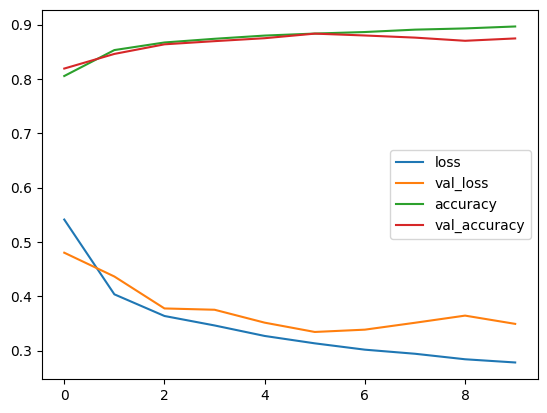

In [57]:
pd.DataFrame(hist.history)[["loss", "val_loss", "accuracy", "val_accuracy"]].plot()

## Evaluar Accuracy
Prueba el rendimiento del modelo con los datos de test

In [62]:
loss, accuaracy = modelo.evaluate(X_test_flat, y_test)

print("Loss: ", loss)
print("AAccuracy: ", accuaracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8648 - loss: 0.3824
Loss:  0.38205766677856445
AAccuracy:  0.8672999739646912


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


## Hacer predicciones

Con el modelo entrenado puedes usarlo para hacer predicciones sobre imagenes.

In [ ]:
pred = modelo.predict(X_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
Primera pred:  Ankle boot


El modelo ha predecido la etiqueta para cada imagen en el set de datos de *test* (prueba). Miremos la primera prediccion:

In [72]:
print("Primera pred: ",class_name[pred[0].argmax()])

Primera pred:  Ankle boot


*Una* prediccion es un array de 10 numeros. Estos representan el nivel de "confianza" del modelo sobre las imagenes de cada uno de los 10 articulos de moda/ropa. Puedes revisar cual tiene el nivel mas alto de confianza:

Entonces, el modelo tiene mayor confianza que esta imagen es un bota de tobillo "ankle boot" o `class_names[9]`. Examinando las etiquetas de *test* o de pruebas muestra que esta clasificación es correcta:

**Grafica** esto para poder ver todo el set de la prediccion de las 10 clases.

Text(0.5, 1.0, 'Ankle boot')

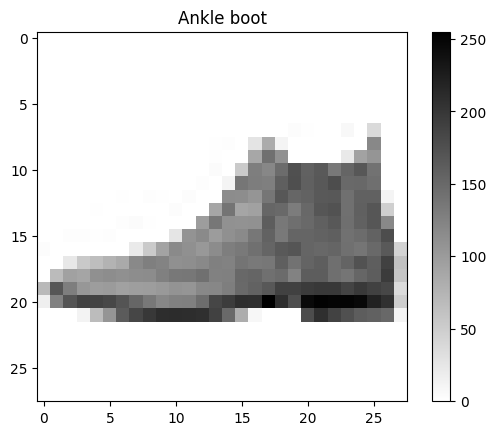

In [85]:
plt.imshow(X_test_f[0], cmap="binary")
plt.colorbar()
plt.title(class_name[pred[0].argmax()])

<BarContainer object of 10 artists>

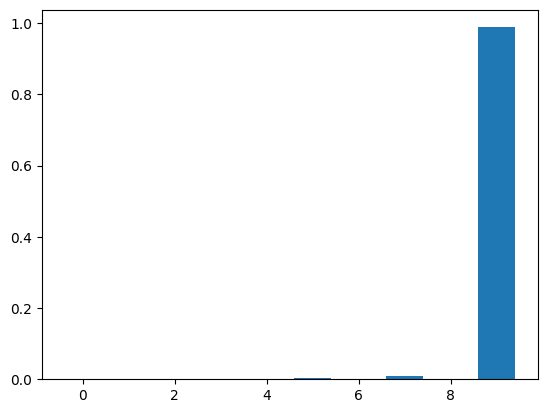

In [87]:
plt.bar(range(10), pred[0])

Vamos a graficar multiples imagenes con sus predicciones. Notese que el modelo puede estar equivocado aun cuando tiene mucha confianza.

In [92]:
class_name[pred[0].max()]

TypeError: list indices must be integers or slices, not numpy.float32

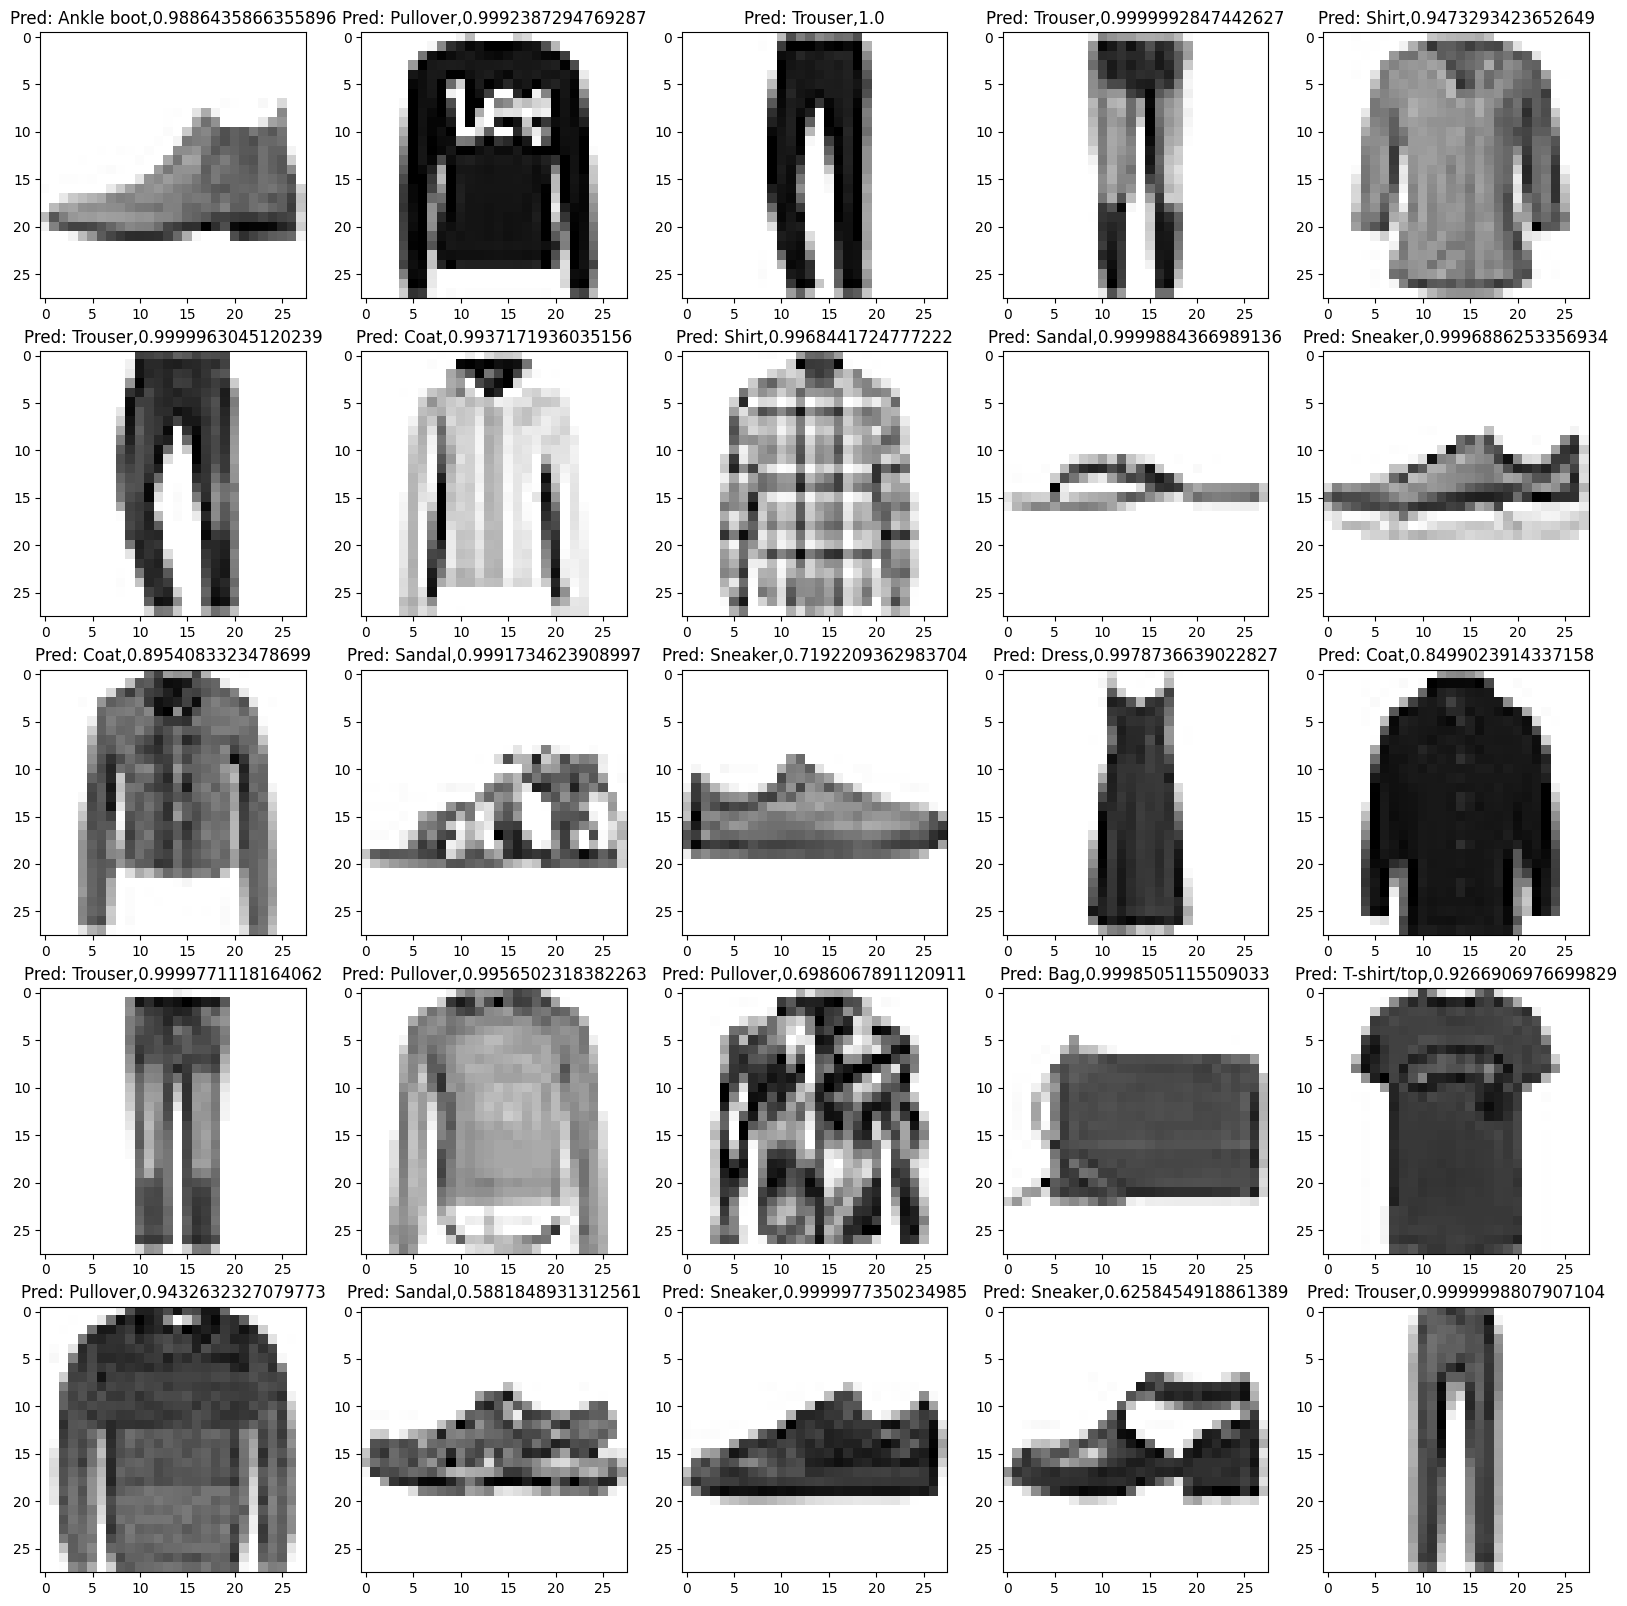

In [93]:
plt.figure(figsize=(20,20))
for i in range(25):
    plt.subplot(5,5, i+1)
    plt.imshow(X_test_f[i], cmap = "binary")
    plt.title(f"Pred: {class_name[pred[i].argmax()]},{pred[i].max()}")

Evalúa tu modelo con una matriz de confusión e interprétala.

In [98]:
len(pred)

10000

<Axes: >

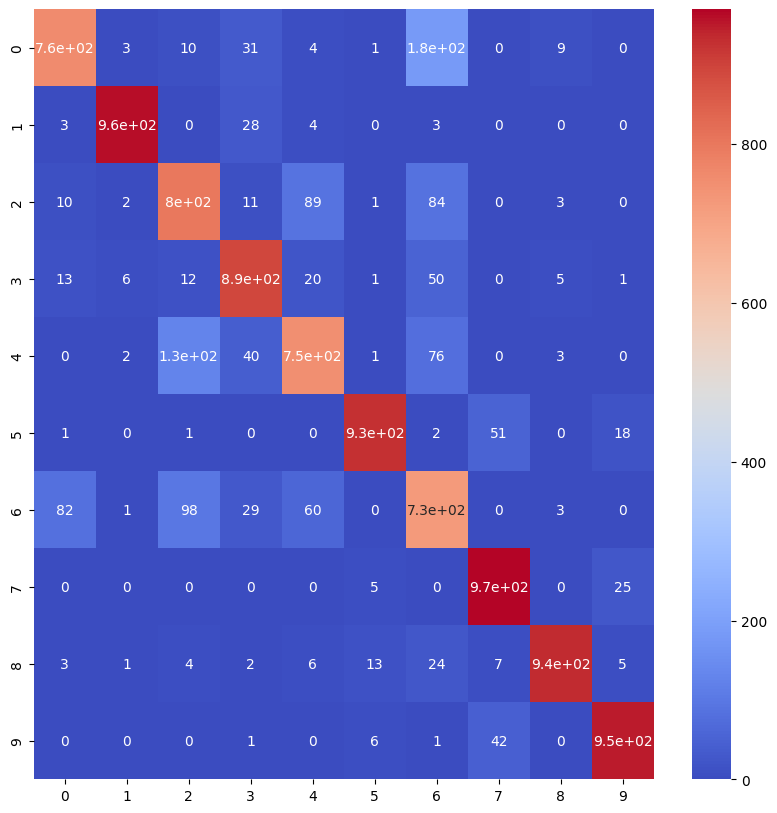

In [105]:
import seaborn as sns

plt.figure(figsize=(10,10))
pred_target = np.argmax(pred, axis=1)
sns.heatmap(metrics.confusion_matrix(y_test_f, pred_target), annot= True , cmap = "coolwarm")

Finalmente, usamos el modelo entrenado para hacer una prediccion sobre una única imagen.

In [108]:
pred = class_name[np.argmax(modelo.predict(X_test_flat[5000:5001]))]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step


Text(0.5, 1.0, 'Pullover')

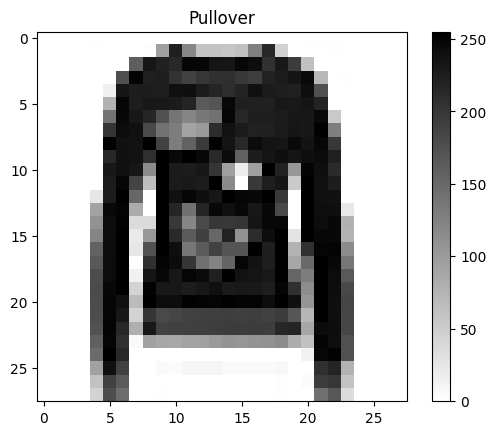

In [111]:
plt.imshow(X_test_f[5000], cmap="binary")
plt.colorbar()
plt.title(pred)